**© 2026 Mindverse Computing LLC.**  
Licensed under CC BY-NC 4.0.  
See LICENSE file for patent and commercial restrictions.

# PhasorFlow v0.2.0 — Complete Circuit Guide

## All 22 Gates · Circuit Diagrams · Statistics · Results

This notebook is a **complete tutorial** for building, visualizing, and running phasor circuits with PhasorFlow. It covers every gate type organized by category:

| Category | Gates | Count |
|----------|-------|-------|
| **Standard Unitary** | Shift, Mix, DFT, Invert, Permute, Reverse | 6 |
| **Aggregation** | Accumulate, GridPropagate | 2 |
| **Non-Linear (Pull-Back)** | Threshold, Saturate, Normalize/PullBack, LogCompress | 4 |
| **Correlation** | CrossCorrelate, Convolve | 2 |
| **Neuromorphic** | Kuramoto, Hebbian, Ising, AsymmetricCouple, Synaptic | 5 |
| **Encoding** | EncodePhase, EncodeAmplitude | 2 |
| **Control** | Barrier, Measure | 2 |

Each section shows:
1. 📐 Circuit construction code
2. 📊 Circuit diagram (text)
3. 📈 Circuit statistics (depth, gates, threads)
4. ✅ Execution results (state vector, phases, amplitudes)

In [2]:
# (c) 2026 Mindverse Computing LLC.
# Licensed under CC BY-NC 4.0.
# See LICENSE file for patent and commercial restrictions.

import sys
import os

sys.path.append(os.path.abspath('..'))

import phasorflow as pf
from phasorflow import PhasorCircuit, Simulator
from phasorflow.engine.analytic import AnalyticEngine
from phasorflow.gates import *
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
engine = AnalyticEngine()

print(f"phasorflow v{pf.__version__} loaded from {os.path.dirname(pf.__file__)}")
print(f"PhasorCircuit has gate_count: {hasattr(PhasorCircuit(1), 'gate_count')}")

def print_circuit_stats(circ):
    print(f"  Circuit Name:   {circ.name}")
    print(f"  Threads:        {circ.num_threads}")
    print(f"  Total Gates:    {circ.gate_count}")
    print(f"  Circuit Depth:  {circ.depth}")
    print(f"  Instructions:   {len(circ)}")

def print_results(result):
    print(f"  State Vector:   {result['state_vector']}")
    print(f"  Phases (rad):   {result['phases']}")
    print(f"  Amplitudes:     {result['amplitudes']}")

phasorflow v0.2.0 loaded from /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/phasorflow
PhasorCircuit has gate_count: True


---
# Part 1: Standard Unitary Gates
Energy-conserving operators on the unit-circle manifold. These preserve total energy.

## 1.1 Shift Gate — Phase Rotation
The most fundamental gate. Rotates a single thread's phasor by angle φ:

$$z_i \rightarrow e^{j\varphi} \cdot z_i$$

A shift of π/2 rotates from 1+0j → 0+1j (quarter turn on the unit circle).

In [3]:
# === Shift Gate Demo ===
circ = PhasorCircuit(1, name="ShiftDemo")
circ.shift(0, math.pi/2)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Gate Matrix ─┐")
sg = ShiftGate()
print(f"  Shift(π/2) = {sg.get_matrix(phi=math.pi/2)}")

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)
print(f"\n  ↳ Phase = {result['phases'][0].item():.4f} rad = π/2 ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(1.57)]──┤

┌─ Gate Matrix ─┐
  Shift(π/2) = tensor([[-0.0000+1.j]])

┌─ Circuit Statistics ─┐
  Circuit Name:   ShiftDemo
  Threads:        1
  Total Gates:    1
  Circuit Depth:  1
  Instructions:   1

┌─ Results ─┐
  State Vector:   tensor([-0.0000+1.j])
  Phases (rad):   tensor([1.5708])
  Amplitudes:     tensor([1.])

  ↳ Phase = 1.5708 rad = π/2 ✓


## 1.2 Invert Gate — Phase Flip (π-Shift)
Special case of Shift with φ=π. Flips the phasor: z → -z.

In [4]:
# === Invert Gate Demo ===
circ = PhasorCircuit(2, name="InvertDemo")
circ.shift(0, math.pi/4)   # Start at π/4
circ.invert(0)              # Flip by π → now at π/4 + π = 5π/4

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)
print(f"\n  ↳ Thread 0: started at π/4, inverted to {result['phases'][0].item():.4f} rad")
print(f"  ↳ Thread 1: untouched at {result['phases'][1].item():.4f} rad")

┌─ Circuit Diagram ─┐
T0: ──[S(0.79)]──[S(3.14)]──┤
                            
T1: ────────────────────────┤

┌─ Circuit Statistics ─┐
  Circuit Name:   InvertDemo
  Threads:        2
  Total Gates:    2
  Circuit Depth:  1
  Instructions:   2

┌─ Results ─┐
  State Vector:   tensor([-0.7071-0.7071j,  1.0000+0.0000j])
  Phases (rad):   tensor([-2.3562,  0.0000])
  Amplitudes:     tensor([1., 1.])

  ↳ Thread 0: started at π/4, inverted to -2.3562 rad
  ↳ Thread 1: untouched at 0.0000 rad


## 1.3 Mix Gate — Beam Splitter (Interference)
The 2-thread unitary interference junction. A 50/50 beam-splitter:

$$\begin{pmatrix} z_a' \\ z_b' \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & j \\ j & 1 \end{pmatrix} \begin{pmatrix} z_a \\ z_b \end{pmatrix}$$

Energy is conserved: $|z_a'|^2 + |z_b'|^2 = |z_a|^2 + |z_b|^2$.

In [5]:
# === Mix Gate Demo ===
circ = PhasorCircuit(2, name="MixDemo")
circ.shift(0, math.pi)  # Thread 0 at phase π
circ.mix(0, 1)           # Interfere threads 0 and 1

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Gate Matrix ─┐")
mg = MixGate()
print(f"  Mix = \n{mg.get_matrix()}")

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)

# Verify energy conservation
e_before = 1.0 + 1.0  # both start at |z|=1
e_after = (result['amplitudes']**2).sum().item()
print(f"\n  ↳ Energy before: {e_before:.4f}")
print(f"  ↳ Energy after:  {e_after:.4f}  {'✓ conserved' if abs(e_before - e_after) < 0.01 else '✗'}")

┌─ Circuit Diagram ─┐
T0: ──[S(3.14)]────┬────┤
                 [MIX]  
T1: ───────────────┴────┤

┌─ Gate Matrix ─┐
  Mix = 
tensor([[0.7071+0.0000j, 0.0000+0.7071j],
        [0.0000+0.7071j, 0.7071+0.0000j]])

┌─ Circuit Statistics ─┐
  Circuit Name:   MixDemo
  Threads:        2
  Total Gates:    2
  Circuit Depth:  1
  Instructions:   2

┌─ Results ─┐
  State Vector:   tensor([-0.7071+0.7071j,  0.7071-0.7071j])
  Phases (rad):   tensor([ 2.3562, -0.7854])
  Amplitudes:     tensor([1.0000, 1.0000])

  ↳ Energy before: 2.0000
  ↳ Energy after:  2.0000  ✓ conserved


## 1.4 DFT Gate — Discrete Fourier Transform
Global spectral transformation across N threads. Maps spatial phases to frequency domain:

$$F_{jk} = \frac{1}{\sqrt{N}} \omega^{jk}, \quad \omega = e^{-2\pi i / N}$$

In [6]:
# === DFT Gate Demo ===
circ = PhasorCircuit(4, name="DFTDemo")
circ.shift(0, math.pi/4)
circ.shift(1, math.pi/2)
circ.dft()

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Gate Matrix (4×4) ─┐")
dg = DFTGate(4)
print(dg.get_matrix())

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)

┌─ Circuit Diagram ─┐
T0: ──[S(0.79)]───────────────┬────┤
                              │    
T1: ─────────────[S(1.57)]────┼────┤
                            [DFT]  
T2: ──────────────────────────┼────┤
                              │    
T3: ──────────────────────────┴────┤

┌─ Gate Matrix (4×4) ─┐
tensor([[ 0.5000+0.0000j,  0.5000+0.0000j,  0.5000+0.0000j,  0.5000+0.0000j],
        [ 0.5000+0.0000j, -0.0000-0.5000j, -0.5000+0.0000j,  0.0000+0.5000j],
        [ 0.5000+0.0000j, -0.5000+0.0000j,  0.5000-0.0000j, -0.5000+0.0000j],
        [ 0.5000+0.0000j,  0.0000+0.5000j, -0.5000+0.0000j, -0.0000-0.5000j]])

┌─ Circuit Statistics ─┐
  Circuit Name:   DFTDemo
  Threads:        4
  Total Gates:    3
  Circuit Depth:  1
  Instructions:   3

┌─ Results ─┐
  State Vector:   tensor([ 1.3536+0.8536j,  0.3536+0.8536j,  0.3536-0.1464j, -0.6464-0.1464j])
  Phases (rad):   tensor([ 0.5626,  1.1781, -0.3927, -2.9188])
  Amplitudes:     tensor([1.6002, 0.9239, 0.3827, 0.6628])


## 1.5 Permute Gate — Thread Reordering
Rearranges threads according to a permutation map. Thread i goes to position permutation[i].

In [7]:
# === Permute Gate Demo ===
circ = PhasorCircuit(4, name="PermuteDemo")
circ.shift(0, 0.1)
circ.shift(1, 0.2)
circ.shift(2, 0.3)
circ.shift(3, 0.4)
circ.barrier()
circ.permute([3, 2, 1, 0])  # Reverse order

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print("  Before permutation: phases = [0.1, 0.2, 0.3, 0.4]")
print(f"  After  permutation: phases = {[round(p.item(), 4) for p in result['phases']]}")
print("  ↳ Thread order reversed ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(0.10)]───────────────────────────────────┤
                                                  
T1: ─────────────[S(0.20)]────────────────────────┤
                                                  
T2: ────────────────────────[S(0.30)]─────────────┤
                                                  
T3: ───────────────────────────────────[S(0.40)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   PermuteDemo
  Threads:        4
  Total Gates:    5
  Circuit Depth:  2
  Instructions:   6

┌─ Results ─┐
  Before permutation: phases = [0.1, 0.2, 0.3, 0.4]
  After  permutation: phases = [0.4, 0.3, 0.2, 0.1]
  ↳ Thread order reversed ✓


## 1.6 Reverse Gate — Time Reversal
Flips all thread order: thread[i] → thread[N-1-i]. Used for palindrome detection and self-correlation.

In [8]:
# === Reverse Gate Demo ===
circ = PhasorCircuit(5, name="ReverseDemo")
for i in range(5):
    circ.shift(i, (i + 1) * 0.5)
circ.barrier()
circ.reverse()

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Before: phases = [0.5, 1.0, 1.5, 2.0, 2.5]")
print(f"  After:  phases = {[round(p.item(), 4) for p in result['phases']]}")
print("  ↳ Thread order flipped ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(0.50)]──────────────────────────────────────────────┤
                                                             
T1: ─────────────[S(1.00)]───────────────────────────────────┤
                                                             
T2: ────────────────────────[S(1.50)]────────────────────────┤
                                                             
T3: ───────────────────────────────────[S(2.00)]─────────────┤
                                                             
T4: ──────────────────────────────────────────────[S(2.50)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   ReverseDemo
  Threads:        5
  Total Gates:    6
  Circuit Depth:  2
  Instructions:   7

┌─ Results ─┐
  Before: phases = [0.5, 1.0, 1.5, 2.0, 2.5]
  After:  phases = [2.5, 2.0, 1.5, 1.0, 0.5]
  ↳ Thread order flipped ✓


---
# Part 2: Aggregation Gates
Summing and propagating wavefronts across threads.

## 2.1 Accumulate Gate — Coherent Summation
Sums all target thread amplitudes into the first target thread. Used for counting, aggregation, and wavefront summation.

In [9]:
# === Accumulate Gate Demo ===
circ = PhasorCircuit(4, name="AccumulateDemo")
circ.shift(0, 0.0)   # 1+0j
circ.shift(1, 0.0)   # 1+0j
circ.shift(2, 0.0)   # 1+0j
circ.shift(3, 0.0)   # 1+0j
circ.barrier()
circ.accumulate([0, 1, 2, 3])

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)
print(f"\n  ↳ Thread 0 accumulated sum: {result['state_vector'][0]}")
print(f"  ↳ All 4 threads summed into thread 0 → amplitude = {result['amplitudes'][0].item():.1f} ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(0.00)]───────────────────────────────────┤
                                                  
T1: ─────────────[S(0.00)]────────────────────────┤
                                                  
T2: ────────────────────────[S(0.00)]─────────────┤
                                                  
T3: ───────────────────────────────────[S(0.00)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   AccumulateDemo
  Threads:        4
  Total Gates:    5
  Circuit Depth:  2
  Instructions:   6

┌─ Results ─┐
  State Vector:   tensor([4.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
  Phases (rad):   tensor([0., 0., 0., 0.])
  Amplitudes:     tensor([4., 1., 1., 1.])

  ↳ Thread 0 accumulated sum: (4+0j)
  ↳ All 4 threads summed into thread 0 → amplitude = 4.0 ✓


---
# Part 3: Non-Linear (Pull-Back) Gates
Constraint-enforcing operators that clip, threshold, or normalize the manifold.

## 3.1 Threshold Gate — Inhibitory Gating
Zeroes out threads whose amplitude falls below a threshold. Survivors are re-normalized to unit amplitude.

In [10]:
# === Threshold Gate Demo ===
circ = PhasorCircuit(4, name="ThresholdDemo")
# Create varying amplitudes by mixing
circ.shift(0, math.pi)
circ.mix(0, 1)       # Splits energy
circ.mix(2, 3)       # Thread 2,3 stay at |z|=1
circ.barrier()
circ.threshold(threshold=0.8)  # Prune < 0.8

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)
print("\n  ↳ Threads with |z| < 0.8 are zeroed out")

┌─ Circuit Diagram ─┐
T0: ──[S(3.14)]────┬───────────┤
                 [MIX]         
T1: ───────────────┴───────────┤
                               
T2: ──────────────────────┬────┤
                        [MIX]  
T3: ──────────────────────┴────┤

┌─ Circuit Statistics ─┐
  Circuit Name:   ThresholdDemo
  Threads:        4
  Total Gates:    4
  Circuit Depth:  2
  Instructions:   5

┌─ Results ─┐
  State Vector:   tensor([-0.7071+0.7071j,  0.7071-0.7071j,  0.7071+0.7071j,  0.7071+0.7071j])
  Phases (rad):   tensor([ 2.3562, -0.7854,  0.7854,  0.7854])
  Amplitudes:     tensor([1., 1., 1., 1.])

  ↳ Threads with |z| < 0.8 are zeroed out


## 3.2 Saturate Gate — Phase Quantization
Snaps phases to N discrete levels (hardware error correction). With levels=2, phases snap to 0 or π.

In [11]:
# === Saturate Gate Demo ===
circ = PhasorCircuit(4, name="SaturateDemo")
circ.shift(0, 0.3)    # Near 0 → snaps to 0
circ.shift(1, 1.2)    # Near π/2 → snaps to π/2 (4 levels)
circ.shift(2, 2.8)    # Near π → snaps to π
circ.shift(3, 5.5)    # Near 2π → snaps to 0
circ.barrier()
circ.saturate(levels=4)  # 4 discrete levels: 0, π/2, π, 3π/2

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Input phases:  [0.3, 1.2, 2.8, 5.5]")
print(f"  Snapped to:    {[round(p.item(), 4) for p in result['phases']]}")
print(f"  All |z| = 1:   {torch.allclose(result['amplitudes'], torch.ones(4), atol=1e-5)} ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(0.30)]───────────────────────────────────┤
                                                  
T1: ─────────────[S(1.20)]────────────────────────┤
                                                  
T2: ────────────────────────[S(2.80)]─────────────┤
                                                  
T3: ───────────────────────────────────[S(5.50)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   SaturateDemo
  Threads:        4
  Total Gates:    5
  Circuit Depth:  2
  Instructions:   6

┌─ Results ─┐
  Input phases:  [0.3, 1.2, 2.8, 5.5]
  Snapped to:    [0.0, 1.5708, -3.1416, -0.0]
  All |z| = 1:   True ✓


## 3.3 Normalize Gate (PullBack) — Unit Circle Projection
The canonical pull-back operator: z/|z|. Forces all amplitudes back to 1 while preserving phase.

In [12]:
# === Normalize Gate Demo ===
circ = PhasorCircuit(3, name="NormalizeDemo")
circ.shift(0, math.pi/4)
circ.shift(1, math.pi/2)
circ.barrier()
circ.accumulate([0, 1, 2])  # Creates non-unit amplitudes
circ.barrier()
circ.normalize()              # Pull back to unit circle

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)
print(f"\n  ↳ All amplitudes = 1.0: {torch.allclose(result['amplitudes'], torch.ones(3), atol=1e-5)} ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(0.79)]─────────────┤
                            
T1: ─────────────[S(1.57)]──┤
                            
T2: ────────────────────────┤

┌─ Circuit Statistics ─┐
  Circuit Name:   NormalizeDemo
  Threads:        3
  Total Gates:    4
  Circuit Depth:  3
  Instructions:   6

┌─ Results ─┐
  State Vector:   tensor([ 0.7071+0.7071j, -0.0000+1.0000j,  1.0000+0.0000j])
  Phases (rad):   tensor([0.7854, 1.5708, 0.0000])
  Amplitudes:     tensor([1., 1., 1.])

  ↳ All amplitudes = 1.0: True ✓


## 3.4 LogCompress Gate — Amplitude Compression
Maps amplitude through log(1 + β|z|) while preserving phase. Prevents combinatorial explosion in counting problems.

In [13]:
# === LogCompress Gate Demo ===
circ = PhasorCircuit(3, name="LogCompressDemo")
# Simulate large amplitudes
circ.shift(0, 0.5)
circ.shift(1, 1.0)
circ.shift(2, 1.5)
circ.barrier()
circ.log_compress(beta=2.0)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)
print(f"\n  ↳ Amplitudes compressed: log(1 + 2·|z|) = {[round(a.item(), 4) for a in result['amplitudes']]}")

┌─ Circuit Diagram ─┐
T0: ──[S(0.50)]────────────────────────┤
                                       
T1: ─────────────[S(1.00)]─────────────┤
                                       
T2: ────────────────────────[S(1.50)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   LogCompressDemo
  Threads:        3
  Total Gates:    4
  Circuit Depth:  2
  Instructions:   5

┌─ Results ─┐
  State Vector:   tensor([0.9641+0.5267j, 0.5936+0.9245j, 0.0777+1.0959j])
  Phases (rad):   tensor([0.5000, 1.0000, 1.5000])
  Amplitudes:     tensor([1.0986, 1.0986, 1.0986])

  ↳ Amplitudes compressed: log(1 + 2·|z|) = [1.0986, 1.0986, 1.0986]


---
# Part 4: Neuromorphic Gates
Bio-inspired dynamic coupling operations for optimization and self-organization.

## 4.1 Kuramoto Gate — Phase Synchronization
Implements Kuramoto coupling dynamics where oscillators synchronize through their neighbors:

$$\frac{d\theta_i}{dt} = K \sum_j w_{ij} \sin(\theta_j - \theta_i)$$

Phases tend toward consensus when coupling is strong.

In [14]:
# === Kuramoto Gate Demo ===
circ = PhasorCircuit(4, name="KuramotoDemo")
# Start with different phases
circ.shift(0, 0.0)
circ.shift(1, 0.5)
circ.shift(2, 1.0)
circ.shift(3, 1.5)
circ.barrier()

# All-to-all coupling
W = torch.ones(4, 4, dtype=torch.float32)
W.fill_diagonal_(0)
for _ in range(20):
    circ.kuramoto(W, dt=0.05, coupling_k=1.0)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Initial phases: [0.00, 0.50, 1.00, 1.50]")
print(f"  After sync:     {[round(p.item(), 4) for p in result['phases']]}")
spread = result['phases'].max() - result['phases'].min()
print(f"  Phase spread:   {spread.item():.4f} rad (converging toward consensus)")

┌─ Circuit Diagram ─┐
T0: ──[S(0.00)]───────────────────────────────────┤
                                                  
T1: ─────────────[S(0.50)]────────────────────────┤
                                                  
T2: ────────────────────────[S(1.00)]─────────────┤
                                                  
T3: ───────────────────────────────────[S(1.50)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   KuramotoDemo
  Threads:        4
  Total Gates:    24
  Circuit Depth:  2
  Instructions:   25

┌─ Results ─┐
  Initial phases: [0.00, 0.50, 1.00, 1.50]
  After sync:     [0.7396, 0.7467, 0.7533, 0.7604]
  Phase spread:   0.0208 rad (converging toward consensus)


## 4.2 Hebbian Gate — Associative Memory
Pulls the state toward stored attractors using Hebbian learning: W = (1/P) · Σ z·z^H. The state relaxes toward the nearest stored pattern.

In [15]:
# === Hebbian Gate Demo ===
# Store two phase patterns
patterns = [
    [0.0, 0.0, math.pi, math.pi],  # Pattern A
    [math.pi, math.pi, 0.0, 0.0],  # Pattern B
]
W = HebbianGate.store_patterns(4, patterns)

circ = PhasorCircuit(4, name="HebbianDemo")
# Start near Pattern A (with noise)
circ.shift(0, 0.1)   # Near 0
circ.shift(1, -0.1)  # Near 0
circ.shift(2, 3.0)   # Near π
circ.shift(3, 3.2)   # Near π
circ.barrier()
for _ in range(10):
    circ.hebbian(W, alpha=0.1)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Stored Pattern A: [0.0, 0.0, π, π]")
print(f"  Noisy Input:      [0.1, -0.1, 3.0, 3.2]")
print(f"  After relaxation: {[round(p.item(), 4) for p in result['phases']]}")
print("  ↳ Converges toward Pattern A ✓")

┌─ Circuit Diagram ─┐
T0: ──[S(0.10)]────────────────────────────────────┤
                                                   
T1: ─────────────[S(-0.10)]────────────────────────┤
                                                   
T2: ─────────────────────────[S(3.00)]─────────────┤
                                                   
T3: ────────────────────────────────────[S(3.20)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   HebbianDemo
  Threads:        4
  Total Gates:    14
  Circuit Depth:  2
  Instructions:   15

┌─ Results ─┐
  Stored Pattern A: [0.0, 0.0, π, π]
  Noisy Input:      [0.1, -0.1, 3.0, 3.2]
  After relaxation: [-0.0177, -0.0228, 3.1177, 3.1228]
  ↳ Converges toward Pattern A ✓


## 4.3 Ising Gate — Binary Phase Coupling
Drives phases toward 0 or π using anti-ferromagnetic coupling. Creates two basins of attraction for binary partition problems like Max-Cut.

In [16]:
# === Ising Gate Demo ===
circ = PhasorCircuit(4, name="IsingDemo")
circ.shift(0, 0.3)
circ.shift(1, 2.5)
circ.shift(2, 0.8)
circ.shift(3, 3.5)
circ.barrier()

# Ring adjacency
A = torch.tensor([
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0]
], dtype=torch.float32)
for _ in range(30):
    circ.ising(A, dt=0.05, coupling_k=1.0)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Initial:   [0.3, 2.5, 0.8, 3.5]")
print(f"  After:     {[round(p.item(), 4) for p in result['phases']]}")
print("  ↳ Phases cluster near 0 or π (binary partition)")

┌─ Circuit Diagram ─┐
T0: ──[S(0.30)]───────────────────────────────────┤
                                                  
T1: ─────────────[S(2.50)]────────────────────────┤
                                                  
T2: ────────────────────────[S(0.80)]─────────────┤
                                                  
T3: ───────────────────────────────────[S(3.50)]──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   IsingDemo
  Threads:        4
  Total Gates:    34
  Circuit Depth:  2
  Instructions:   35

┌─ Results ─┐
  Initial:   [0.3, 2.5, 0.8, 3.5]
  After:     [0.2034, -2.9388, 0.205, -2.936]
  ↳ Phases cluster near 0 or π (binary partition)


---
# Part 5: Encoding Gates
Convert classical data into phasor representations.

## 5.1 EncodePhase Gate — Values → Phases
Maps classical values to phase angles: θ = (x / max_val) · 2π. Produces unit-amplitude phasors.

In [17]:
# === EncodePhase Gate Demo ===
circ = PhasorCircuit(5, name="EncodePhaseDemo")
values = [0.0, 25.0, 50.0, 75.0, 100.0]
circ.encode_phases(values, max_val=100.0)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Input values: {values}")
print(f"  Encoded phases: {[round(p.item(), 4) for p in result['phases']]}")
print(f"  All |z| = 1:    {torch.allclose(result['amplitudes'], torch.ones(5), atol=1e-5)} ✓")

┌─ Circuit Diagram ─┐
T0: ──┤
      
T1: ──┤
      
T2: ──┤
      
T3: ──┤
      
T4: ──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   EncodePhaseDemo
  Threads:        5
  Total Gates:    1
  Circuit Depth:  1
  Instructions:   1

┌─ Results ─┐
  Input values: [0.0, 25.0, 50.0, 75.0, 100.0]
  Encoded phases: [0.0, 1.5708, -3.1416, -1.5708, 0.0]
  All |z| = 1:    True ✓


## 5.2 EncodeAmplitude Gate — Values → Amplitudes
Encodes values as phasor amplitudes at phase 0: z = value + 0j.

In [18]:
# === EncodeAmplitude Gate Demo ===
circ = PhasorCircuit(4, name="EncodeAmplitudeDemo")
values = [1.0, 2.5, 5.0, 10.0]
circ.encode_amplitudes(values)

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Input values:     {values}")
print(f"  Encoded amplitudes: {[round(a.item(), 4) for a in result['amplitudes']]}")
print(f"  All phases ≈ 0:   {torch.allclose(result['phases'], torch.zeros(4), atol=1e-5)} ✓")

┌─ Circuit Diagram ─┐
T0: ──┤
      
T1: ──┤
      
T2: ──┤
      
T3: ──┤

┌─ Circuit Statistics ─┐
  Circuit Name:   EncodeAmplitudeDemo
  Threads:        4
  Total Gates:    1
  Circuit Depth:  1
  Instructions:   1

┌─ Results ─┐
  Input values:     [1.0, 2.5, 5.0, 10.0]
  Encoded amplitudes: [1.0, 2.5, 5.0, 10.0]
  All phases ≈ 0:   True ✓


---
# Part 6: Control Instructions & Circuit Composition
Barriers, measurements, composition, and repetition.

## 6.1 Barrier & Measure
- **Barrier**: Synchronization point marking layer boundaries
- **Measure**: Snapshot the state at a specific point in the circuit

In [19]:
# === Barrier & Measure Demo ===
circ = PhasorCircuit(3, name="ControlDemo")
circ.shift(0, math.pi/4)
circ.shift(1, math.pi/2)
circ.barrier()              # Layer separator
circ.mix(0, 1)
circ.barrier()
circ.measure("after_mix")   # Snapshot
circ.normalize()
circ.measure("after_norm")  # Another snapshot

print("┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print(f"  Final state:  {result['state_vector']}")
print(f"  Measurements: {list(result['measurements'].keys())}")
for label, snap in result['measurements'].items():
    if isinstance(snap, dict):
        print(f"    '{label}': phases = {[round(p.item(), 4) for p in snap['phases']]}")

┌─ Circuit Diagram ─┐
T0: ──[S(0.79)]───────────────┬────┤
                            [MIX]  
T1: ─────────────[S(1.57)]────┴────┤
                                   
T2: ───────────────────────────────┤

┌─ Circuit Statistics ─┐
  Circuit Name:   ControlDemo
  Threads:        3
  Total Gates:    4
  Circuit Depth:  3
  Instructions:   8

┌─ Results ─┐
  Final state:  tensor([-0.3827+0.9239j, -0.3827+0.9239j,  1.0000+0.0000j])
  Measurements: ['after_mix', 'after_norm']
    'after_mix': phases = [1.9635, 1.9635, 0.0]
    'after_norm': phases = [1.9635, 1.9635, 0.0]


## 6.2 Compose & Repeat
- **Compose**: Append one circuit's instructions to another
- **Repeat**: Duplicate current instructions N times

In [20]:
# === Compose Demo ===
circ_a = PhasorCircuit(3, name="CircuitA")
circ_a.shift(0, 0.5).shift(1, 1.0)

circ_b = PhasorCircuit(3, name="CircuitB")
circ_b.mix(0, 1).mix(1, 2)

circ_a.compose(circ_b)
print("┌─ Composed Circuit ─┐")
print_circuit_stats(circ_a)
pf.draw(circ_a, mode='text')

# === Repeat Demo ===
circ_r = PhasorCircuit(2, name="RepeatDemo")
circ_r.shift(0, 0.1)
circ_r.repeat(5)  # Repeat 5x → total shift = 0.5

print("\n┌─ Repeated Circuit ─┐")
print_circuit_stats(circ_r)
result = engine.run(circ_r)
print(f"  Shift(0.1) × 5 = {result['phases'][0].item():.4f} rad (expected ~0.5) ✓")

┌─ Composed Circuit ─┐
  Circuit Name:   CircuitA
  Threads:        3
  Total Gates:    4
  Circuit Depth:  1
  Instructions:   4
T0: ──[S(0.50)]───────────────┬───────────┤
                            [MIX]         
T1: ─────────────[S(1.00)]────┴──────┬────┤
                                   [MIX]  
T2: ─────────────────────────────────┴────┤

┌─ Repeated Circuit ─┐
  Circuit Name:   RepeatDemo
  Threads:        2
  Total Gates:    5
  Circuit Depth:  1
  Instructions:   5
  Shift(0.1) × 5 = 0.5000 rad (expected ~0.5) ✓


---
# Part 7: Complete Pipeline — All Categories Combined

A realistic circuit combining encoding → unitary → neuromorphic → pull-back → measure.

In [21]:
# === Full Pipeline Demo ===
circ = PhasorCircuit(6, name="FullPipeline")

# Layer 1: Encode input data
values = [10, 20, 30, 40, 50, 60]
circ.encode_phases(values, max_val=100.0)
circ.barrier()

# Layer 2: Mix adjacent pairs (beam splitters)
circ.mix(0, 1)
circ.mix(2, 3)
circ.mix(4, 5)
circ.barrier()

# Layer 3: DFT for spectral analysis
circ.dft()
circ.barrier()

# Layer 4: Threshold to keep strong signals
circ.threshold(threshold=0.5)
circ.barrier()

# Layer 5: Normalize back to unit circle
circ.normalize()
circ.barrier()

# Layer 6: Saturate to 4 discrete levels
circ.saturate(levels=4)
circ.barrier()

# Measure
circ.measure("final")

print("┌─ Full Pipeline Circuit ─┐")
pf.draw(circ, mode='text')

print("\n┌─ Circuit Statistics ─┐")
print_circuit_stats(circ)

print("\n┌─ Results ─┐")
result = engine.run(circ)
print_results(result)

┌─ Full Pipeline Circuit ─┐
T0: ────┬────────────────────┬────┤
      [MIX]                  │    
T1: ────┴────────────────────┼────┤
                             │    
T2: ───────────┬─────────────┼────┤
             [MIX]         [DFT]  
T3: ───────────┴─────────────┼────┤
                             │    
T4: ──────────────────┬──────┼────┤
                    [MIX]    │    
T5: ──────────────────┴──────┴────┤

┌─ Circuit Statistics ─┐
  Circuit Name:   FullPipeline
  Threads:        6
  Total Gates:    8
  Circuit Depth:  7
  Instructions:   15

┌─ Results ─┐
  State Vector:   tensor([-1.-0.0000j,  1.+0.0000j,  1.+0.0000j,  1.+0.0000j, -1.-0.0000j,
        -1.-0.0000j])
  Phases (rad):   tensor([-3.1416,  0.0000,  0.0000,  0.0000, -3.1416, -3.1416])
  Amplitudes:     tensor([1., 1., 1., 1., 1., 1.])


## Visualization — Full Pipeline Results

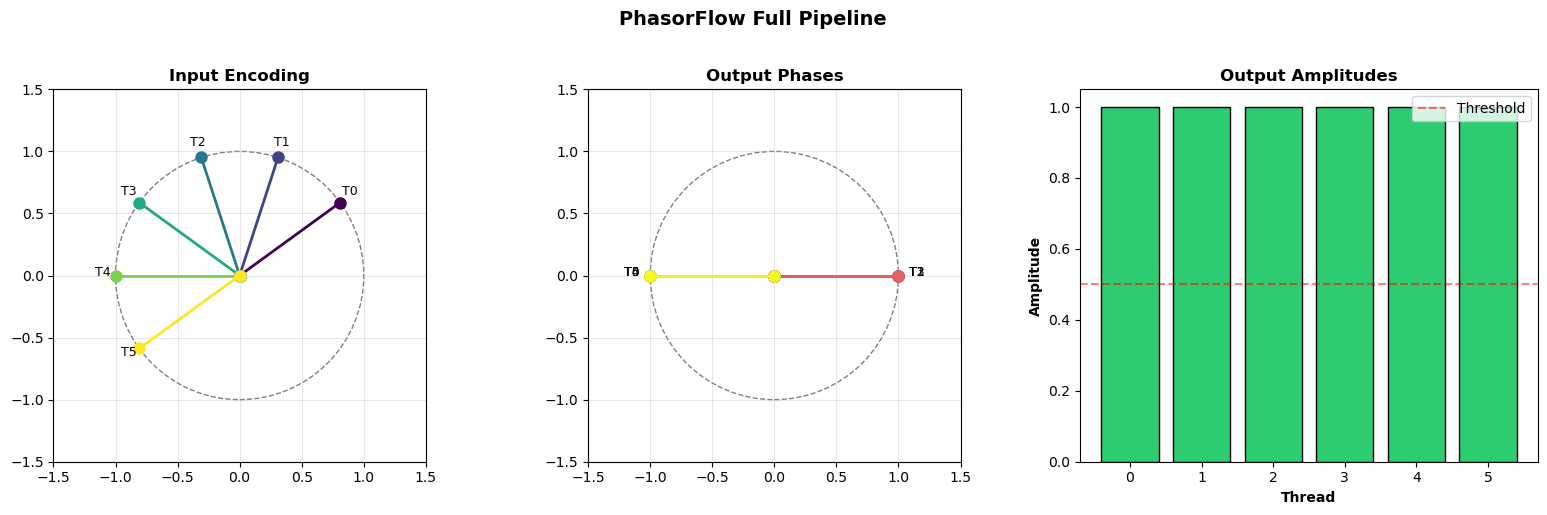

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Input encoding
ax = axes[0]
theta = [v/100 * 2 * math.pi for v in values]
for i, t in enumerate(theta):
    ax.plot([0, math.cos(t)], [0, math.sin(t)], 'o-',
            color=plt.cm.viridis(i/5), linewidth=2, markersize=8)
    ax.text(1.1*math.cos(t), 1.1*math.sin(t), f'T{i}', fontsize=9, ha='center')
circle = plt.Circle((0,0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.set_title('Input Encoding', fontweight='bold')
ax.grid(True, alpha=0.3)

# 2) Output phases on unit circle
ax = axes[1]
phases = result['phases']
for i, p in enumerate(phases):
    ax.plot([0, math.cos(p)], [0, math.sin(p)], 'o-',
            color=plt.cm.plasma(i/5), linewidth=2, markersize=8)
    ax.text(1.15*math.cos(p), 1.15*math.sin(p), f'T{i}', fontsize=9, ha='center')
circle = plt.Circle((0,0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.set_title('Output Phases', fontweight='bold')
ax.grid(True, alpha=0.3)

# 3) Amplitude bar chart
ax = axes[2]
amps = result['amplitudes'].detach().numpy()
colors = ['#2ecc71' if a > 0.5 else '#e74c3c' for a in amps]
ax.bar(range(6), amps, color=colors, edgecolor='black')
ax.set_xlabel('Thread', fontweight='bold')
ax.set_ylabel('Amplitude', fontweight='bold')
ax.set_title('Output Amplitudes', fontweight='bold')
ax.set_xticks(range(6))
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold')
ax.legend()

plt.suptitle('PhasorFlow Full Pipeline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('full_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 8: Gate Reference Summary

| # | Gate | Category | Threads | Description |
|---|------|----------|---------|-------------|
| 1 | `shift(i, φ)` | Standard | 1 | Phase rotation by φ |
| 2 | `invert(i)` | Standard | 1 | π-shift (phase flip) |
| 3 | `mix(a, b)` | Standard | 2 | 50/50 beam splitter |
| 4 | `dft()` | Standard | N | Discrete Fourier Transform |
| 5 | `permute(perm)` | Standard | N | Thread reordering |
| 6 | `reverse()` | Standard | N | Time reversal |
| 7 | `accumulate(tgts)` | Aggregation | N | Coherent summation |
| 8 | `grid_propagate(r,c)` | Aggregation | N | 2D wavefront DP |
| 9 | `threshold(t)` | Pull-Back | N | Inhibitory gating |
| 10 | `saturate(L)` | Pull-Back | N | Phase quantization |
| 11 | `normalize()` | Pull-Back | N | Unit circle projection |
| 12 | `pullback()` | Pull-Back | N | Alias for normalize |
| 13 | `log_compress(β)` | Pull-Back | N | Amplitude compression |
| 14 | `cross_correlate(p)` | Correlation | N | Sliding-window coherence |
| 15 | `convolve()` | Correlation | N | Self-convolution |
| 16 | `kuramoto(W)` | Neuromorphic | N | Phase synchronization |
| 17 | `hebbian(W)` | Neuromorphic | N | Associative relaxation |
| 18 | `ising(A)` | Neuromorphic | N | Binary 0/π coupling |
| 19 | `asymmetric_couple(D)` | Neuromorphic | N | Directional DAG |
| 20 | `encode_phases(v)` | Encoding | N | Values → phases |
| 21 | `encode_amplitudes(v)` | Encoding | N | Values → amplitudes |
| 22 | `barrier()` | Control | — | Layer separator |
| 23 | `measure(label)` | Control | N | State snapshot |

> **PhasorFlow v0.2.0** — 22 gates, professional PyTorch-based phasor computing framework for machine learning.